In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import *


In [2]:
# 신경망 구성에 필요한 라이브러리 임포트

import torch
from torch import nn            # nn 모듈
from torch.optim import Adam    # 최적화

# 파이토치에서 데이터 다룰 때 사용하는 도구
from torch.utils.data import TensorDataset, DataLoader  
# data 모듈 안에 class 두 개(TensorDataset(텐서로 만들기), DataLoader(데이터 적재))

In [3]:
# 디바이스 준비 (GPU, CPU)
# 파이토치 설치: GPU 버전으로 파이토치 설치 -> GPU도 사용할 수 있고, CPU도 사용할 수 있음.
# CPU버전으로 설치하면 CPU만 사용하게 된다. '
# cuda에서 병렬로 내적 처리
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)


cuda


In [4]:
# 데이터 전처리 1
# 데이터 불러오기
path = 'https://bit.ly/advertising_csv'
adv = pd.read_csv(path)


# x, y 분할
target = 'Sales'
x = adv.drop(target, axis=1)
y = adv.loc[:, target]


# 학습/검증 데이터 분리
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=20)
print(type(x_train), type(x_val))


# 스케일링
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
print(type(x_train), type(x_val))

# ndarray는 안 됨. 텐서여야 함.

<class 'pandas.DataFrame'> <class 'pandas.DataFrame'>
<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [5]:
# 데이터 전처리 2
# 텐서 변환 : tensor() 함수 사용
x_train_ts = torch.tensor(x_train, dtype=torch.float32)     # tensor의 데이터 타입이 float32

# y_train은 Series. Series는 Tensor 변환이 안 됨. so, y_train.value(ndarray)만 가지고 나와서 변환.(ndarray => tensor 변환)
y_train_ts = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)  # 텐서 들어갈 때 2차원으로 들어가야 함.(.view(-1, 1) torch의 tensor 오브젝트 메소드. 2차원 변환)
x_val_ts = torch.tensor(x_val, dtype=torch.float32)
y_val_ts = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)


# to 메소드는 x_train_ts 오브젝트 안에 있는 메소드(x_train_ts는 tensor의 메소드. so, tensor가 아니면 to 메소드 사용할 수 없음.)
# 디바이스 할당 (CPU(RAM)에서 작업한 것 -> GPU(VRAM(cuda))로 )
# RAM에서 쓴 거 GPU에서 쓰고 싶으면 VRAM으로 이동해서 GPU에 사용해야 함.
# device : cuda  CPU -> GPU 이동
x_train_ts, y_train_ts = x_train_ts.to(device), y_train_ts.to(device)
x_val_ts, y_val_ts = x_val_ts.to(device), y_val_ts.to(device)
# to(이동할 장치 지정) 메소드: 데이터 이동
# device : cpu   GPU -> CPU 이동


# 필요한 만큼만 GPU로 이동.(GPU(VRAM)용량 한계)

In [6]:
# 강사님 꺼.
# # 데이터 전처리 2
# # 텐서 변환 : tensor() 함수 사용
# x_train_ts = torch.tensor(x_train, dtype=torch.float32)
# # y_train 는  Series 다 => 텐서 변환이 안된다. y_train.values (ndarrary) => tensor 변환
# # y_train.values (ndarrary) => tensor 변환 => 1차원이다. => 신경망에 들어갈 때 2차원이어야 한다.
# # 그래서 1차원 2차원으로 변환이 필요하다 : .view(-1, 1) => torch의 tensor 오브젝트 메소드, 2차원 변환
# y_train_ts = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
# x_val_ts = torch.tensor(x_val, dtype=torch.float32)
# y_val_ts = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)


# # to메소드 : x_train_ts(tensor) 오브젝트 안에 있는 메소드
# # to(이동할 장치 지정) 메소드 : 데이터 이동
# # 디바이스 할당 : CPU(RAM) => GPU(VRAM)
# # device = 'cuda'
# x_train_ts, y_train_ts = x_train_ts.to(device), y_train_ts.to(device)
# x_val_ts, y_val_ts = x_val_ts.to(device), y_val_ts.to(device)
# # device : cpu => GPU => CPU 이동
# # device='cpu'
# # x_train_ts, y_train_ts = x_train_ts.to(device), y_train_ts.to(device)
# # x_val_ts, y_val_ts = x_val_ts.to(device), y_val_ts.to(device)

In [7]:
# 1. 학습에 사용할 텐서 데이터셋 생성
# 1.1. 배치 사이즈: 전체 데이터에서 한 번 학습에 사용할 데이터 크기 지정
BATCH_SIZE = 32     # 32개씩 들어가게 하겠다. 한 번에 학습할 데이터량     # 대문자는 상수

# 1.2. 텐서 데이터셋 생성 => 데이터 준비 완료
train_ds = TensorDataset(x_train_ts, y_train_ts)

# 2. 데이터 로더 구성: 데이터(train_ds)를 모델에 넣어주는 것.
# 한 번 학습에 32개씩 데이터 넣겠다.
train_loader = DataLoader(
    train_ds,                   # 전체 데이터
    batch_size=BATCH_SIZE,      # 한 번 학습에 사용할 데이터 개수
    shuffle=True                # 섞겠다.
)

In [8]:
# 데이터 준비 완료
# 데이터 전처리 1 
# => 데이터 전처리 2 : 텐서 변환, GPU 이동
# => 학습에 사용할 데이터 집합 생성: TensorDataset
# => 모델에 데이터를 넣어줌: DataLoader
# 위 순서로 진행.

In [9]:
# 신경망 생성 모델
# 1. 모델 구조 생성: 3가지 방법이 있다. => 가장 쉬운 방법. 쉽지만 정밀하게 제어는 어렵.
# 모델(신경망) 구조
# 1.1. 신경망 : shape[1] => 입력 행렬의 열의 크기 -> 신경망의 행의 크기가 되어야 내적 가능
#               입력행렬의 열 == 신경망 행
in_features = x_train_ts.shape[1]

# 1.2. 신경망 생성하고 GPU로 보냄.(데이터는 GPU에 있음.)
model = nn.Sequential(          # RAM에 들어감.
    nn.Linear(in_features, 1)   # (입력개수, 출력개수)      # 입력개수를 in_features(입력행렬의 열의 크기)에 맞추겠다.
    ).to(device)                # VRAM으로 이동.


In [10]:
# 학습 방법을 지정: 손실함수, 옵티마이저 구성
loss_fn = nn.MSELoss()  # 손실함수 지정
# model.parameters() : w 추출 -> 학습, lr: 학습률
optimizer = Adam(model.parameters(), lr=0.01)  # parameters는 w(weight)

In [ ]:
# 학습 진행
EPOCHS = 100        # 반복 횟수
tr_loss_list, val_loss_list = [], []


# 1. 학습 데이터 반복 학습
for epoch in range(EPOCHS):     # 100번 반복
    model.train() # 모델 학습 모드로 변경. eval() 평가 모드로 변경.
    total_loss = 0.0    # 전체 오차
    n_batch = 0         # 배치 개수


    # 2. 에포크마다 배치 단위 학습
    for x, y in train_loader:   # 데이터를 모델에 넣어주는 것.(배치 사이즈만큼씩 넣어줌.) data 100개, 배치사이즈 32라면 4번 for 돌아감.
        x, y = x.to(device), y.to(device)   # cuda로 보냄.


        # 3. 학습
        # 순전파(Feed Forward Learning): 학습 데이터에서 오차 계산
        pred = model(x) # 모델에 x를 입력해 예측    pred: 모델을 통과해서 나온 예측값(1개. nn.Linear의 출력 개수 1개로 지정)
        # loss = loss_fn(pred, y) # 오차 계산        pred(예측값) - y(원래답)


        # 오차 역전파(Backward Learning): 오차로부터 가중치 업데이트
        loss = loss_fn(pred, y) # 오차 계산        pred(예측값) - y(원래답)    여기부터 역전파 시작.
        optimizer.zero_grad() # 기울기(gradient) 초기화
        loss.backward() # 손실 함수를 기준으로 각 가중치의 기울기를 계산
        optimizer.step() # 기울기를 기준으로 가중치 조정


        total_loss += loss.item()
        n_batch += 1


    # 에포크마다 학습 오차 집계
    tr_loss = total_loss / n_batch  # RAM


    # 4. 검증
    model.eval() # 모델 평가/추론 모드로 변경
    with torch.no_grad():   # no_grad : no_gradient. 기울기 없이. 미분하지 마라. 학습하지 마라.(미분 자체가 학습)
        val_pred = model(x_val_ts)  # 예측값 추출
        val_loss = loss_fn(val_pred, y_val_ts)  # 오차 구해야 함.   # val_loss는 gpu에 저장


    tr_loss_list.append(tr_loss)    # RAM
    val_loss_list.append(val_loss.item())   # item()은 dict. vram에서 ram으로 넘어감. item() 빠지면 vram에 있음.
    # train loss : 학습 데이터에 대한 오차, val loss : 테스트 데이터에 대한 오차
    print(f'Epoch {epoch+1 : 4d} | train loss {tr_loss:.4f} | val loss {val_loss:.4f}')

Epoch    1 | train loss 8.4649 | val loss 13.8566
Epoch    2 | train loss 8.4154 | val loss 13.7837
Epoch    3 | train loss 8.3558 | val loss 13.7146
Epoch    4 | train loss 8.2990 | val loss 13.6494
Epoch    5 | train loss 8.2479 | val loss 13.5856
Epoch    6 | train loss 8.1981 | val loss 13.5230
Epoch    7 | train loss 8.1528 | val loss 13.4598
Epoch    8 | train loss 8.1003 | val loss 13.4012
Epoch    9 | train loss 8.0570 | val loss 13.3421
Epoch   10 | train loss 8.0115 | val loss 13.2849
Epoch   11 | train loss 7.9673 | val loss 13.2296
Epoch   12 | train loss 7.9284 | val loss 13.1735
Epoch   13 | train loss 7.8845 | val loss 13.1203
Epoch   14 | train loss 7.8432 | val loss 13.0694
Epoch   15 | train loss 7.8074 | val loss 13.0175
Epoch   16 | train loss 7.7718 | val loss 12.9658
Epoch   17 | train loss 7.7333 | val loss 12.9164
Epoch   18 | train loss 7.6959 | val loss 12.8692
Epoch   19 | train loss 7.6605 | val loss 12.8236
Epoch   20 | train loss 7.6263 | val loss 12.7793


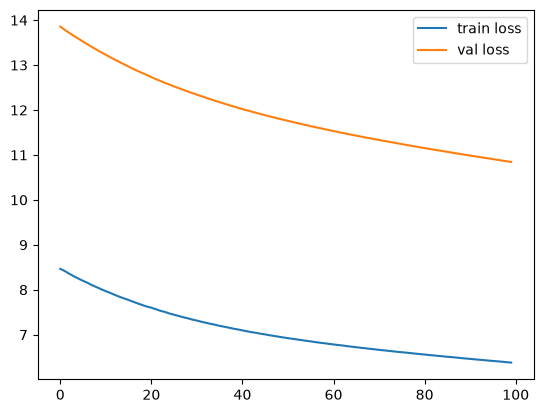

In [16]:
plt.plot(tr_loss_list, label='train loss')
plt.plot(val_loss_list, label='val loss')
plt.legend()
plt.show()
# 세로축: 오차, 가로축: 반복횟수
# 반복횟수 많아질 수록 오차 줄어듦.

In [ ]:
# 예측
model.eval()
with torch.no_grad():
    # pred_val = model(x_val_ts).numpy()    # model: cuda 로 보냄   # gpu에 있는 걸 np로 바꿀 수 x(cpu에서 해야.)   
    pred_val = model(x_val_ts).cpu().numpy()    # model(x_val_ts) 결과 예측값 tensor에 저장.    # 예측값을 cpu로 이동해서 np 변경.
    # pred_val은 cpu에 있음.
    # 명시적인 cpu 이동.

# true_val = y_val_ts.numpy()       # gpu에 있기 때문에 np로 할 수 없음.
true_val = y_val_ts.cpu().numpy()   # cpu로 옮겨서 np로 변경.


In [18]:
# 평가
print(f'RMSE : {root_mean_squared_error(true_val, pred_val):.4f}')
print(f'MAE : {mean_absolute_error(true_val, pred_val):.4f}')
print(f'R2 : {r2_score(true_val, pred_val):.4f}')


RMSE : 3.2931
MAE : 2.5242
R2 : 0.7003
